In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 400
import seaborn as sns

In [2]:
df = pd.read_csv("realistic_balanced_chat_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   conversation_id  500 non-null    int64 
 1   patient_message  500 non-null    object
 2   doctor_response  500 non-null    object
 3   intent           500 non-null    object
 4   sentiment        500 non-null    object
 5   summary          500 non-null    object
 6   key_points       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [3]:
df.columns

Index(['conversation_id', 'patient_message', 'doctor_response', 'intent',
       'sentiment', 'summary', 'key_points'],
      dtype='object')

In [4]:
df['intent'].value_counts()

intent
general_questions      85
discuss_symptoms       84
ask_prescription       83
request_appointment    83
follow_up              83
complaint              82
Name: count, dtype: int64

In [5]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\arfit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arfit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\arfit/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
import re 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [7]:
df.head()

,conversation_id,patient_message,doctor_response,intent,sentiment,summary,key_points
0,1,I've been waiting 45 minutes past my scheduled...,The administrative team will conduct a thoroug...,complaint,formal,Patient reported dissatisfaction or issues. Co...,"waiting, minutes, scheduled, appointment, time."
1,2,What COVID safety measures are you currently f...,We accept most major insurance plans. May I ha...,general_questions,neutral,Patient asked general information about servic...,"COVID, safety, measures, currently, following?"
2,3,The antidepressant dosage doesn't seem effecti...,"Hey, thanks for the heads-up about running low...",ask_prescription,friendly,Patient asked for medication renewal or advice...,"antidepressant, dosage, doesn't, effective, an..."
3,4,Your online portal isn't working and I can't a...,This level of service is completely unacceptab...,complaint,negative,Patient reported dissatisfaction or issues. Co...,"online, portal, isn't, working, can't"
4,5,I'd like to make a same-day urgent appointment...,I can help with that. Would you prefer an earl...,request_appointment,neutral,Patient requested a future consultation. Commu...,"same-day, urgent, appointment, possible."


In [8]:
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments,AutoModelForSequenceClassification
from datasets import Dataset
import joblib 

C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
req_df = df[["patient_message","sentiment"]]
req_df.dropna()
req_df.head()

,patient_message,sentiment
0,I've been waiting 45 minutes past my scheduled...,formal
1,What COVID safety measures are you currently f...,neutral
2,The antidepressant dosage doesn't seem effecti...,friendly
3,Your online portal isn't working and I can't a...,negative
4,I'd like to make a same-day urgent appointment...,neutral


In [10]:
le = LabelEncoder()
req_df['label'] = le.fit_transform(df['sentiment'])

C:\Users\arfit\AppData\Local\Temp\ipykernel_25320\556692872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  req_df['label'] = le.fit_transform(df['sentiment'])


In [11]:
req_df

,patient_message,sentiment,label
0,I've been waiting 45 minutes past my scheduled...,formal,2
1,What COVID safety measures are you currently f...,neutral,5
2,The antidepressant dosage doesn't seem effecti...,friendly,3
3,Your online portal isn't working and I can't a...,negative,4
4,I'd like to make a same-day urgent appointment...,neutral,5
...,...,...,...
495,My child needs a sports physical - do you have...,neutral,5
496,The doctor didn't explain my diagnosis clearly...,apologetic,0
497,There's sharp pain in my lower right abdomen t...,urgent,7
498,Do you accept my new insurance plan?,friendly,3


In [12]:
joblib.dump(le,"sentiment_label_encoded.pkl")
req_df[['sentiment','label']].drop_duplicates().sort_values('label')

,sentiment,label
11,apologetic,0
5,concerned,1
0,formal,2
2,friendly,3
3,negative,4
1,neutral,5
6,positive,6
15,urgent,7


In [13]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenis(text):
    return tokenizer(text['patient_message'], truncation = True, padding = "max_length")

In [14]:
dataset = Dataset.from_pandas(req_df[['patient_message', 'label']])
dataset = dataset.train_test_split(test_size=0.2)
dataset = dataset.map(tokenis, batched=True)

Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3193.32 examples/s]


In [15]:
num_labels = req_df['label'].nunique()
model = AutoModelForSequenceClassification.from_pretrained(
    "j-hartmann/emotion-english-distilroberta-base", 
    num_labels=num_labels,
ignore_mismatched_sizes=True )

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at j-hartmann/emotion-english-distilroberta-base and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([8, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([8]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
training_args = TrainingArguments(
    output_dir="C:/works/task_agenixai/sentiment_model",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
)

In [17]:
#  Define Metrics
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average="weighted")
    }


In [18]:
# Train the Model
st_trainer_model = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics
)

st_trainer_model.train()

Step,Training Loss


TrainOutput(global_step=150, training_loss=2.0310009765625, metrics={'train_runtime': 655.8264, 'train_samples_per_second': 1.83, 'train_steps_per_second': 0.229, 'total_flos': 158977887436800.0, 'train_loss': 2.0310009765625, 'epoch': 3.0})

In [19]:
# Evaluate
st_trainer_model.evaluate()

# Optional: Classification Report
preds_output = st_trainer_model.predict(dataset['test'])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

  apologetic       0.67      0.22      0.33         9
   concerned       0.57      0.25      0.35        16
      formal       0.00      0.00      0.00        13
    friendly       0.00      0.00      0.00         6
    negative       0.00      0.00      0.00        11
     neutral       0.23      0.95      0.37        21
    positive       0.50      0.07      0.12        14
      urgent       0.00      0.00      0.00        10

    accuracy                           0.27       100
   macro avg       0.25      0.19      0.15       100
weighted avg       0.27      0.27      0.18       100



C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

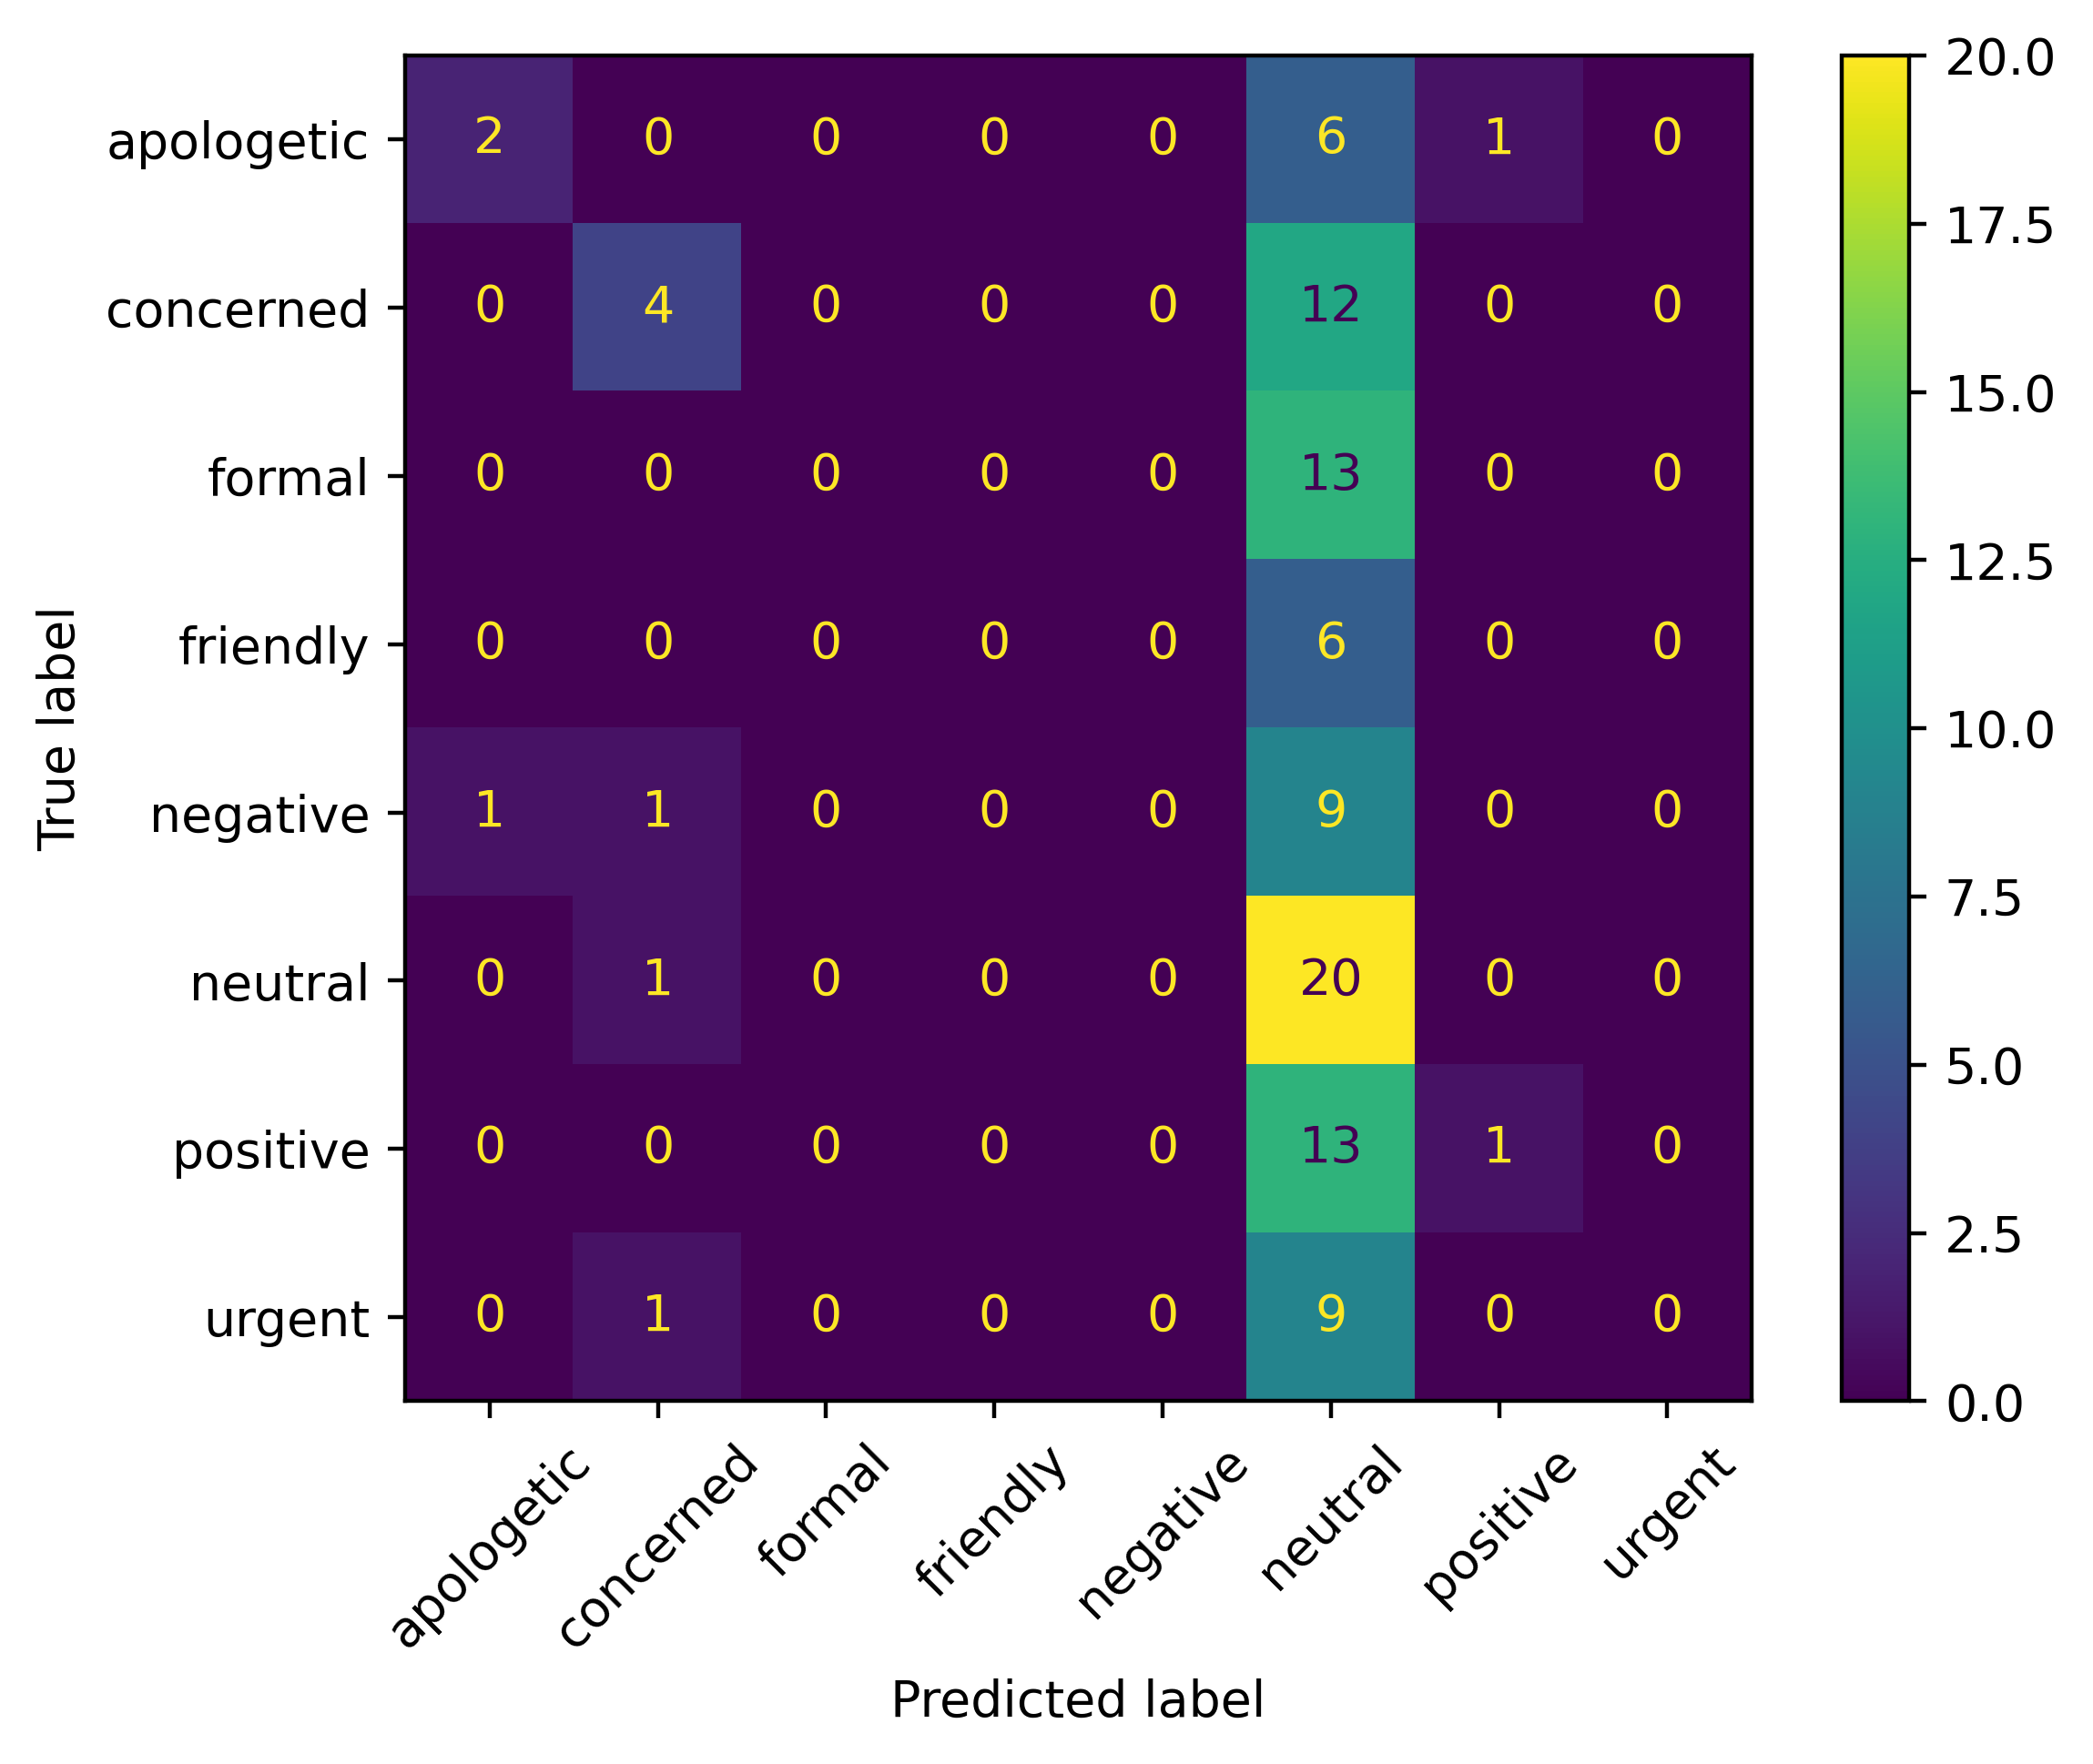

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=le.classes_, xticks_rotation=45)


In [21]:
st_trainer_model.save_model("C:/works/task_agenixai/sentiment_model")

In [22]:
from pathlib import Path
model_path = Path("C:/works/task_agenixai/sentiment_model")

In [23]:
from transformers import pipeline

# Load your trained pipeline
classifier = pipeline("text-classification", model=model_path, tokenizer=tokenizer)

# Assuming you used LabelEncoder and it's named 'le'
def predict_intent(text):
    result = classifier(text)[0]
    label_index = int(result['label'].split('_')[-1])  # Get the numeric part from 'LABEL_4'
    class_name = le.inverse_transform([label_index])[0]
    print(f"Predicted Intent: {class_name} (Confidence: {round(result['score'], 2)})")


# Example
predict_intent("Doc thank you for the surgery now i can walk again")

Device set to use cpu


Predicted Intent: neutral (Confidence: 0.23)
